## Jackknife and Bootstrap Variance Estimation
---
* Generates R=1000 samples from an exponential distribution.

* For each sample, estimates variance of:

    * the mean (smooth)

    * the median (non-smooth)

* Compares:

    * True sampling variance (from the R repetitions)

    * Jackknife estimated variance

    * Bootstrap estimated variance

Plots the distribution of estimated variances.

In [ ]:
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt
np.random.seed(42)

# Configuration
n = 100          # Sample size
B = 1000         # Bootstrap repetitions
R = 1000         # Monte Carlo replications
true_var = {}    # To store true variance for mean and median

# Statistic functions
def get_stat(x, kind='mean'):
    return np.mean(x) if kind == 'mean' else np.median(x)

# Storage
results = {'mean': {'jackknife': [], 'bootstrap': [], 'true': []},
           'median': {'jackknife': [], 'bootstrap': [], 'true': []}}

for kind in ['mean', 'median']:
    for _ in range(R):
        # Generate a sample from a skewed distribution
        data = np.random.exponential(scale=2.0, size=n)
        theta = get_stat(data, kind=kind)
        # ---- Jackknife ----
        jack_vals = np.array([
            get_stat(np.delete(data, i), kind=kind) for i in range(n)
        ])
        jack_mean = np.mean(jack_vals)
        var_jack = (n - 1) / n * np.sum((jack_vals - jack_mean) ** 2)
        # ---- Bootstrap ----
        boot_vals = np.array([
            get_stat(resample(data), kind=kind) for _ in range(B)
        ])
        var_boot = np.var(boot_vals, ddof=1)
        # Save
        results[kind]['jackknife'].append(var_jack)
        results[kind]['bootstrap'].append(var_boot)
        results[kind]['true'].append(get_stat(data, kind=kind))
# Compute true variance using Monte Carlo
for kind in ['mean', 'median']:
    stat_vals = results[kind]['true']
    true_var[kind] = np.var(stat_vals, ddof=1)


In [5]:
# Print results
print("Variance Estimation Comparison (n = {}, B = {}, R = {})".format(n, B, R))
for kind in ['mean', 'median']:
    mean_jack = np.mean(results[kind]['jackknife'])
    mean_boot = np.mean(results[kind]['bootstrap'])
    print(f"\nStatistic: {kind.capitalize()}")
    print(f"  True Variance       : {true_var[kind]:.6f}")
    print(f"  Jackknife Estimate  : {mean_jack:.6f}")
    print(f"  Bootstrap Estimate  : {mean_boot:.6f}")


Variance Estimation Comparison (n = 100, B = 1000, R = 1000)

Statistic: Mean
  True Variance       : 0.043816
  Jackknife Estimate  : 0.040055
  Bootstrap Estimate  : 0.039749

Statistic: Median
  True Variance       : 0.040193
  Jackknife Estimate  : 0.076710
  Bootstrap Estimate  : 0.044305


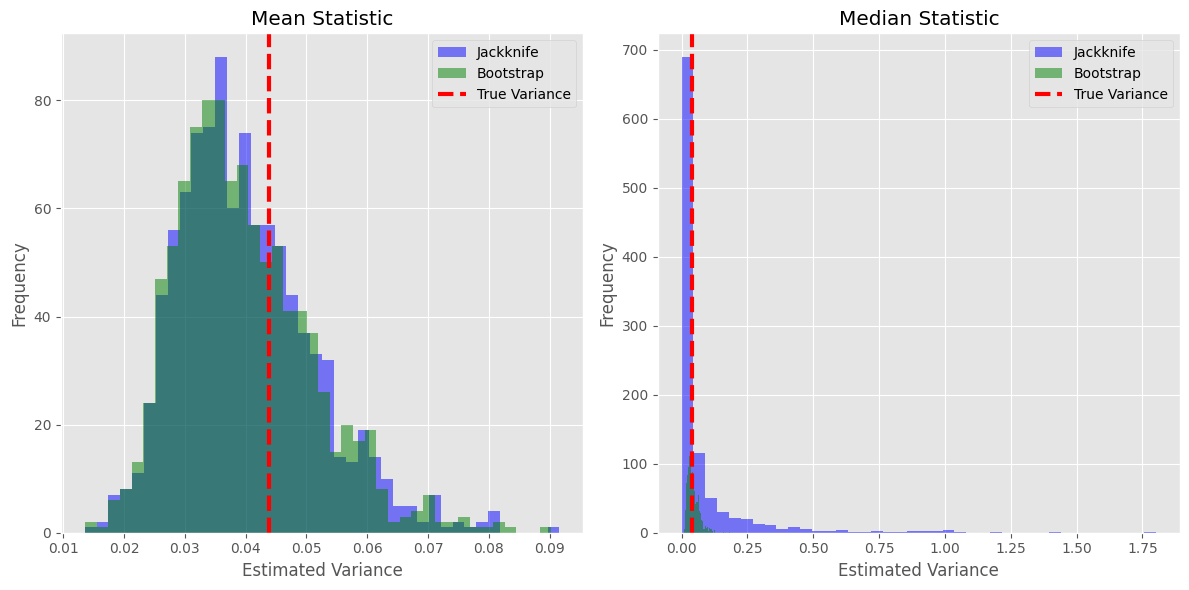

In [26]:
# Plotting
# enhance the resolution of the plot
plt.rcParams['figure.dpi'] = 100
plt.figure(figsize=(12, 6))
plt.style.use('ggplot') 
for i, kind in enumerate(['mean', 'median']):
    plt.subplot(1, 2, i+1)
    plt.hist(results[kind]['jackknife'], bins=40, alpha=0.5,color='blue', label='Jackknife')
    plt.hist(results[kind]['bootstrap'], bins=40, alpha=0.5, color='green', label='Bootstrap')
    plt.axvline(true_var[kind], color='red',linewidth=3, linestyle='dashed', label='True Variance')
    #add grid lines
    plt.title(f"{kind.capitalize()} Statistic")
    plt.xlabel("Estimated Variance")
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()
